In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import utils

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_seed_distance_distribution(
    ballots,
    ballot_counts,
    n_trials,
    sampling_rate,
    all_candidates,
    distance_fn="kendall",
    n_bins=30
):
    """
    Compute and plot the distribution of distances from each (non-seed)
    individual ballot to its closest seed ballot, averaged over many trials.

    New parameter:
    -------------
    all_candidates : list
        List of ALL candidate IDs appearing anywhere in the election.
        Used to define consistent default ranks for Footrule distance.

    Other behavior remains unchanged.
    """

    # ------------------------------
    # Distance functions
    # ------------------------------

    def kendall_tau_distance_partial(b1, b2):
        """Kendall tau distance for partial rankings (only common candidates)."""
        pos1 = {cand: idx for idx, cand in enumerate(b1)}
        pos2 = {cand: idx for idx, cand in enumerate(b2)}
        common = [c for c in pos1 if c in pos2]

        dist = 0
        for i in range(len(common)):
            ci = common[i]
            for j in range(i + 1, len(common)):
                cj = common[j]
                i1, j1 = pos1[ci], pos1[cj]
                i2, j2 = pos2[ci], pos2[cj]
                if (i1 - j1) * (i2 - j2) < 0:
                    dist += 1
        return dist

    def footrule_distance_partial(b1, b2):
        """
        Spearman footrule distance for partial rankings.
        Missing candidates receive default rank = len(all_candidates),
        rather than len(ballot), which ensures consistent treatment.
        """
        pos1 = {cand: idx for idx, cand in enumerate(b1)}
        pos2 = {cand: idx for idx, cand in enumerate(b2)}

        default_rank = len(all_candidates)

        dist = 0
        for c in all_candidates:
            r1 = pos1.get(c, default_rank)
            r2 = pos2.get(c, default_rank)
            dist += abs(r1 - r2)
        return dist

    def edit_distance_partial(b1, b2):
        """Levenshtein edit distance between two ballot sequences."""
        m, n = len(b1), len(b2)
        if m == 0:
            return n
        if n == 0:
            return m

        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                cost_sub = 0 if b1[i - 1] == b2[j - 1] else 1
                dp[i][j] = min(
                    dp[i - 1][j] + 1,        # deletion
                    dp[i][j - 1] + 1,        # insertion
                    dp[i - 1][j - 1] + cost_sub  # substitution
                )
        return dp[m][n]

    def ballot_distance(b1, b2, name):
        name = name.lower()
        if name == "kendall":
            return kendall_tau_distance_partial(b1, b2)
        elif name == "footrule":
            return footrule_distance_partial(b1, b2)
        elif name == "edit":
            return edit_distance_partial(b1, b2)
        else:
            raise ValueError(f"Unsupported distance_fn '{name}'.")

    # ------------------------------
    # Input processing
    # ------------------------------

    ballots = [list(b) for b in ballots]
    ballot_counts = np.asarray(ballot_counts, dtype=int)
    n_types = len(ballots)

    if n_types == 0:
        raise ValueError("ballots must be non-empty.")
    if ballot_counts.shape[0] != n_types:
        raise ValueError("ballot_counts must match ballots length.")
    if not (0 < sampling_rate < 1):
        raise ValueError("sampling_rate must be in (0,1).")

    total_ballots = int(ballot_counts.sum())
    all_candidates = list(all_candidates)

    rng = np.random.default_rng()
    all_distances = []

    # ------------------------------
    # Trials
    # ------------------------------
    for _ in range(n_trials):

        # Number of seed INSTANCES per type
        seed_instance_counts = rng.binomial(ballot_counts, sampling_rate)
        if seed_instance_counts.sum() == 0:
            # force one instance to be a seed
            probs = ballot_counts / ballot_counts.sum()
            idx_force = rng.choice(np.arange(n_types), p=probs)
            seed_instance_counts[idx_force] = 1

        nonseed_instance_counts = ballot_counts - seed_instance_counts

        seed_types = np.where(seed_instance_counts > 0)[0]
        nonseed_types = np.where(nonseed_instance_counts > 0)[0]

        if len(nonseed_types) == 0:
            continue  # nothing to collect this trial

        seed_ballots = [ballots[i] for i in seed_types]

        for idx in nonseed_types:
            b = ballots[idx]
            min_d = min(ballot_distance(b, sb, distance_fn) for sb in seed_ballots)

            # Add this distance once per NON-SEED instance
            all_distances.extend([min_d] * int(nonseed_instance_counts[idx]))

    # ------------------------------
    # Plot + return distribution
    # ------------------------------
    all_distances = np.asarray(all_distances, dtype=float)

    fig, ax = plt.subplots()
    ax.hist(all_distances, bins=n_bins)
    ax.set_xlabel("Distance to closest seed ballot")
    ax.set_ylabel("Density")
    ax.set_title(f"Seed distance distribution ({distance_fn})")
    plt.show()

    return all_distances


In [3]:
burlington_filename = "../data/preflib/elections-all/burlington/ED-00005-00000002.toi"

ballots, ballot_counts, cand_names, skipped_votes = \
    utils.read_preflib(burlington_filename)

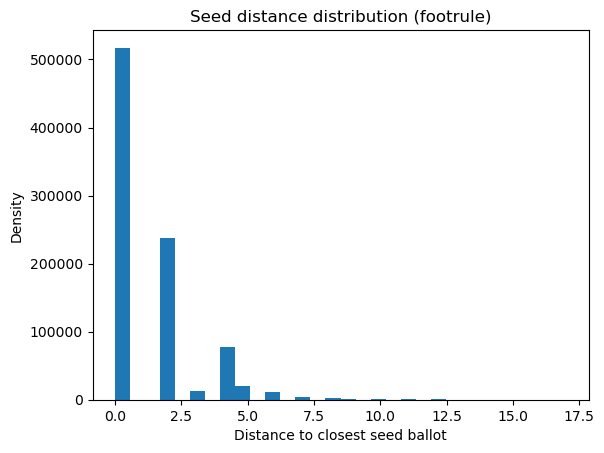

array([0., 0., 0., ..., 4., 9., 6.])

In [4]:
plot_seed_distance_distribution(ballots, ballot_counts,
                                n_trials=100, 
                                sampling_rate=0.01, 
                                all_candidates=list(cand_names.keys()), 
                                distance_fn="footrule")

In [4]:
SMALL_SIZE = 18
MEDIUM_SIZE = 24
BIGGER_SIZE = 24
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [6]:
import pickle

election_name = "burlington-02"
with open(f"../results/preflib-resampling/debug/{election_name}.pkl", "rb") as pickleFile:
    results = pickle.load(pickleFile)
results

{'fig_name': 'burlington-02',
 'sampling_rates': [0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 1.0],
 'oracle_means': [0.476,
  0.571,
  0.805,
  0.8049999999999999,
  0.763,
  0.9180000000000001,
  1.0],
 'oracle_stds': [0.48676893902548873,
  0.44065746334312783,
  0.33656351555092845,
  0.35195880440756133,
  0.34694524063604043,
  0.13753544997563355,
  0.0],
 'forecaster_means': {},
 'forecaster_stds': {'Contextual By Length': [[0.48666621004544786,
    0.45825756949558394,
    0.49749371855331],
   [0.30000000000000004, 0.30000000000000004, 0.49011325221830104],
   [0.4330127018922193, 0.4248234927590516, 0.49749371855331004],
   [0.4974937185533099, 0.4313362957136809, 0.4330127018922193],
   [0.4330127018922193, 0.18743265457224892, 0.21847425477616347],
   [0.4330127018922193, 0.34348799105645594, 0.45825756949558394],
   [0.21794494717703364, 0.21794494717703364, 0.21794494717703364]],
  'Mallows Dispersion 1': [[0.4552405957293352, 0.0, 0.5],
   [0.21794494717703364, 0.0, 0.462397015

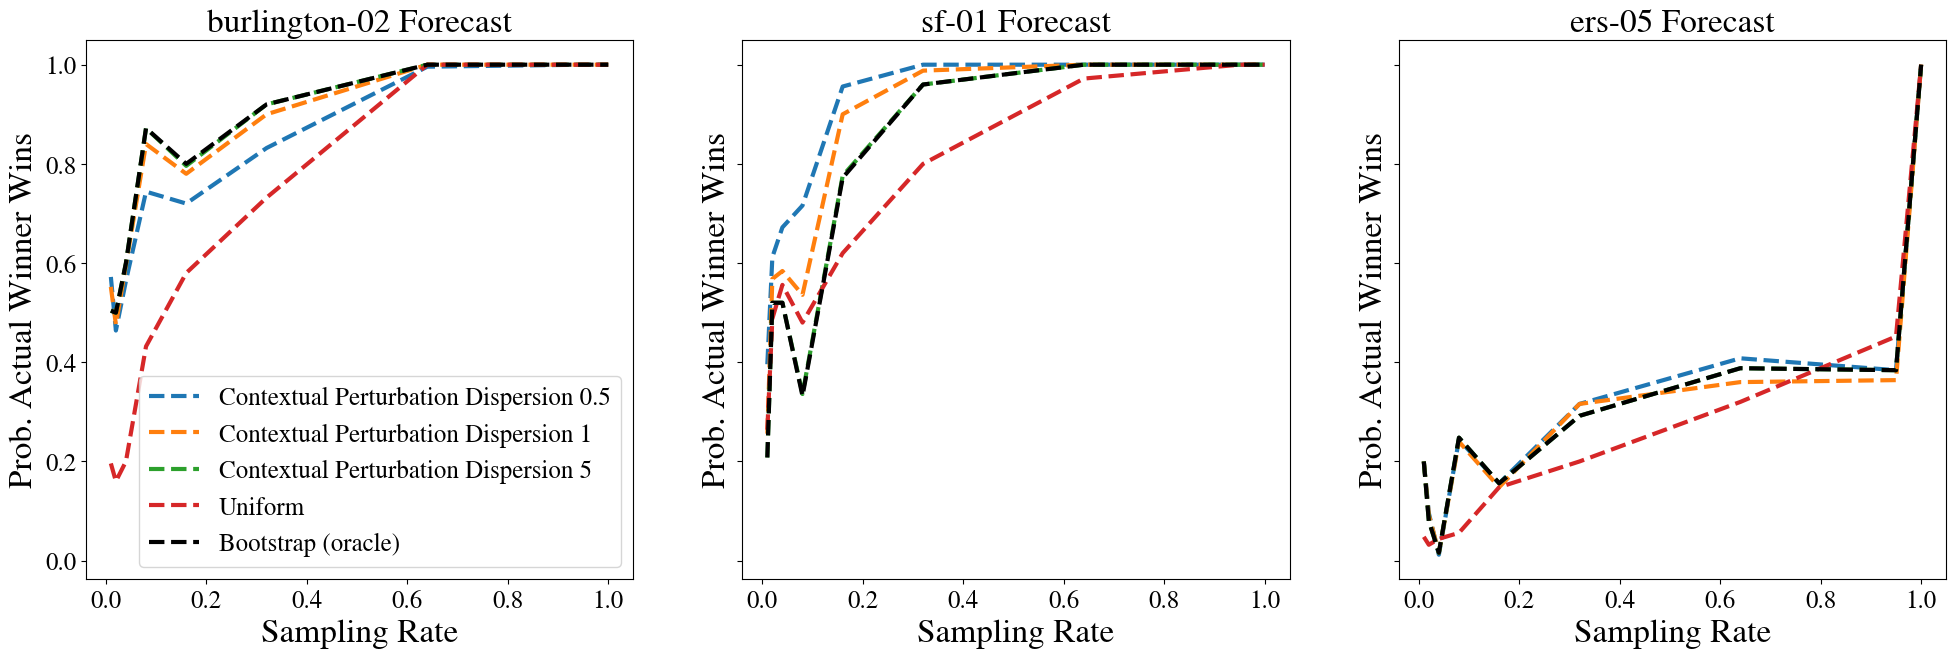

In [41]:
fig, axs = plt.subplots(ncols=3, figsize=(24, 7), sharex=True, sharey=True)
elections = ["burlington-02", "sf-01", "ers-05"]

for election_idx, election_name in enumerate(elections):
    with open(f"../results/preflib-resampling/debug/{election_name}.pkl", "rb") as pickleFile:
        results = pickle.load(pickleFile)

    ax = axs[election_idx]

    for forecaster_idx, (forecaster_name, forecaster_means) in enumerate(
        results["forecaster_means"].items()
    ):
        # Optionally skip double-plotting the oracle if it's in the dict
        if forecaster_name == "Bootstrap":
            continue

        if "Contextual Perturbation" not in forecaster_name and forecaster_name != "Uniform":
            continue
            
        ax.plot(
            results["sampling_rates"],
            forecaster_means,
            linestyle="--",
            linewidth=3,
            # color=utils.colors[forecaster_idx % len(utils.colors)],
            label=forecaster_name,
        )

    ax.plot(
        results["sampling_rates"],
        results["oracle_means"],
        color="black",
        linestyle="--",
        linewidth=3,
        label="Bootstrap (oracle)",
    )
    
    ax.set_xlabel("Sampling Rate")
    # ax.set_xscale("log")
    ax.set_ylabel("Prob. Actual Winner Wins")
    ax.set_title(f"{election_name} Forecast")
    if election_idx == 0:
        ax.legend()

# lines_labels = [axs[-1].get_legend_handles_labels()]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, ncol=10)

Contextual By Length
Mallows Dispersion 1
Contextual Perturbation Dispersion 1
Uniform


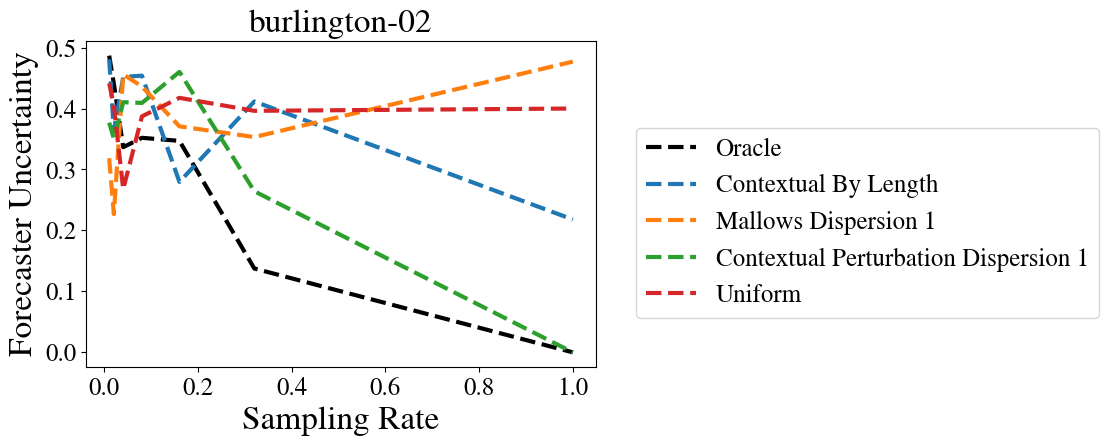

In [15]:
election_name = "burlington-02"
with open(f"../results/preflib-resampling/debug/{election_name}.pkl", "rb") as pickleFile:
    results = pickle.load(pickleFile)

fig, ax = plt.subplots()

ax.plot(
    results["sampling_rates"],
    results["oracle_stds"],
    linestyle="--",
    linewidth=3,
    label="Oracle",
    color="black"
)

for sampler_name, sampler_stds in results["forecaster_stds"].items():
    print(sampler_name)
    stds = [np.mean(trials) for trials in sampler_stds]
    
    ax.plot(
        results["sampling_rates"],
        stds,
        linestyle="--",
        linewidth=3,
        label=sampler_name,
    )

ax.set_xlabel("Sampling Rate")
ax.set_ylabel("Forecaster Uncertainty")
ax.set_title(f"{election_name}")

# ax.set_xscale("log")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
fig.tight_layout()